# MSE802 Quantum Computing: Assessment 2

## Task 2: Qiskit circuits

This task has two parts:

- **Part A:** A specified two-qubit circuit is built in Qiskit, simulated locally, and executed on the Quokka device. The circuit applies a Hadamard gate to the first qubit, a Pauli-X gate to the second qubit, and a controlled-NOT gate between them, in order to prepare the entangled Bell state $|\Psi^+\rangle = \tfrac{1}{\sqrt2}(|01\rangle + |10\rangle)$.
- **Part B:** A custom circuit is constructed and executed on the Quokka device, in order to demonstrate a quantum algorithm that respects the device's supported gate set.

In [1]:
'''libraries'''
import requests
from collections import Counter
from qiskit import QuantumCircuit, qasm2
from qiskit.quantum_info import Statevector, DensityMatrix
from qiskit_aer import AerSimulator
from IPython.display import display, Markdown
from qiskit.visualization import plot_histogram, plot_distribution

## Part A — Preparing the Bell State $|\Psi^+\rangle$

The specified circuit applies a Hadamard gate to qubit 0, a Pauli-X gate to qubit 1, and then a controlled-NOT gate with qubit 0 as the control and qubit 1 as the target. The Hadamard gate places qubit 0 in an equal superposition; the Pauli-X gate flips qubit 1 to $|1\rangle$; and the controlled-NOT gate entangles the two qubits, so that the circuit prepares the Bell state $|\Psi^+\rangle$.

```
 q0 ──[ H ]────■────(measure)
               │
 q1 ──[ X ]──[ X ]──(measure)
```

**What To Expect:** Because $|\Psi^+\rangle = \tfrac{1}{\sqrt2}(|01\rangle + |10\rangle)$, the two qubits are anti-correlated; therefore, only the outcomes `01` and `10` should occur, each with a probability of approximately 50%, whereas the outcomes `00` and `11` should be absent. An ideal simulator produces exactly this distribution, and a noise-free device is expected to reproduce it.

### A.1 Build the Circuit in Qiskit

In [2]:
qc = QuantumCircuit(2)
qc.h(0)                    # superposition on qubit 0
qc.x(1)                    # flip qubit 1 to |1>
qc.cx(0, 1)                # entangle: control q0, target q1

# Capture the pre-measurement state vector before the measurement collapses it
state = Statevector.from_instruction(qc)

qc.measure_all()           # measure both qubits into a classical register

print(qc.draw(output="text"))

        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        ├───┤┌─┴─┐ ░ └╥┘┌─┐
   q_1: ┤ X ├┤ X ├─░──╫─┤M├
        └───┘└───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


### The State the Circuit Prepares

The circuit prepares the Bell state

$$
|\Psi^+\rangle = \frac{1}{\sqrt{2}}\left(|01\rangle + |10\rangle\right).
$$

Starting from the initial state $|00\rangle$, the Hadamard gate is applied to qubit 0, which places that qubit in an equal superposition of $|0\rangle$ and $|1\rangle$. The Pauli-X gate then flips qubit 1 from $|0\rangle$ to $|1\rangle$. Finally, the controlled-NOT gate uses qubit 0 as the control and qubit 1 as the target, so that qubit 1 is inverted whenever qubit 0 is $|1\rangle$; this operation entangles the two qubits and yields the Bell state $|\Psi^+\rangle$.

The state $|\Psi^+\rangle$ differs from the standard Bell state $|\Phi^+\rangle$, which produces the correlated outcomes $|00\rangle$ and $|11\rangle$. Whereas $|\Phi^+\rangle$ is correlated, $|\Psi^+\rangle$ is anti-correlated; consequently, a measurement of both qubits returns $|01\rangle$ with a probability of approximately 50% and $|10\rangle$ with a probability of approximately 50%. In an ideal simulator the outcomes $|00\rangle$ and $|11\rangle$ never occur, because their amplitudes are exactly zero; however, when the circuit is executed on physical hardware, a small number of these outcomes may appear as a result of gate imperfections and measurement noise (Nielsen & Chuang, 2010).

### A.2 Inspect the State Vector (Before Measurement)

In [3]:
print("Amplitudes :", state.data)
display(Markdown("State vector:"), state.draw(output="latex"))

Amplitudes : [0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]


State vector:

<IPython.core.display.Latex object>

### A.3 Run on the Local Aer Simulator (1024 Shots)

In order to verify the circuit before it is sent to the Quokka device, the circuit is executed on Qiskit's local Aer simulator for 1024 shots; the resulting counts provide an ideal, noise-free reference against which the device output can later be compared.

In [4]:
# 1. Setup the Aer backend
simulator = AerSimulator()

# 2. Run the simulation and get results
job = simulator.run(qc, shots=1024)
result = job.result()

# 3. Get and print the counts
counts = result.get_counts()
print("Aer Simulation counts:", counts)


Aer Simulation counts: {'01': 488, '10': 536}


### A.4 Visualise the Results

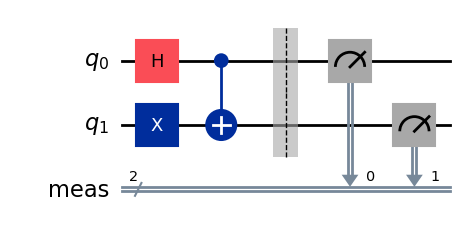

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

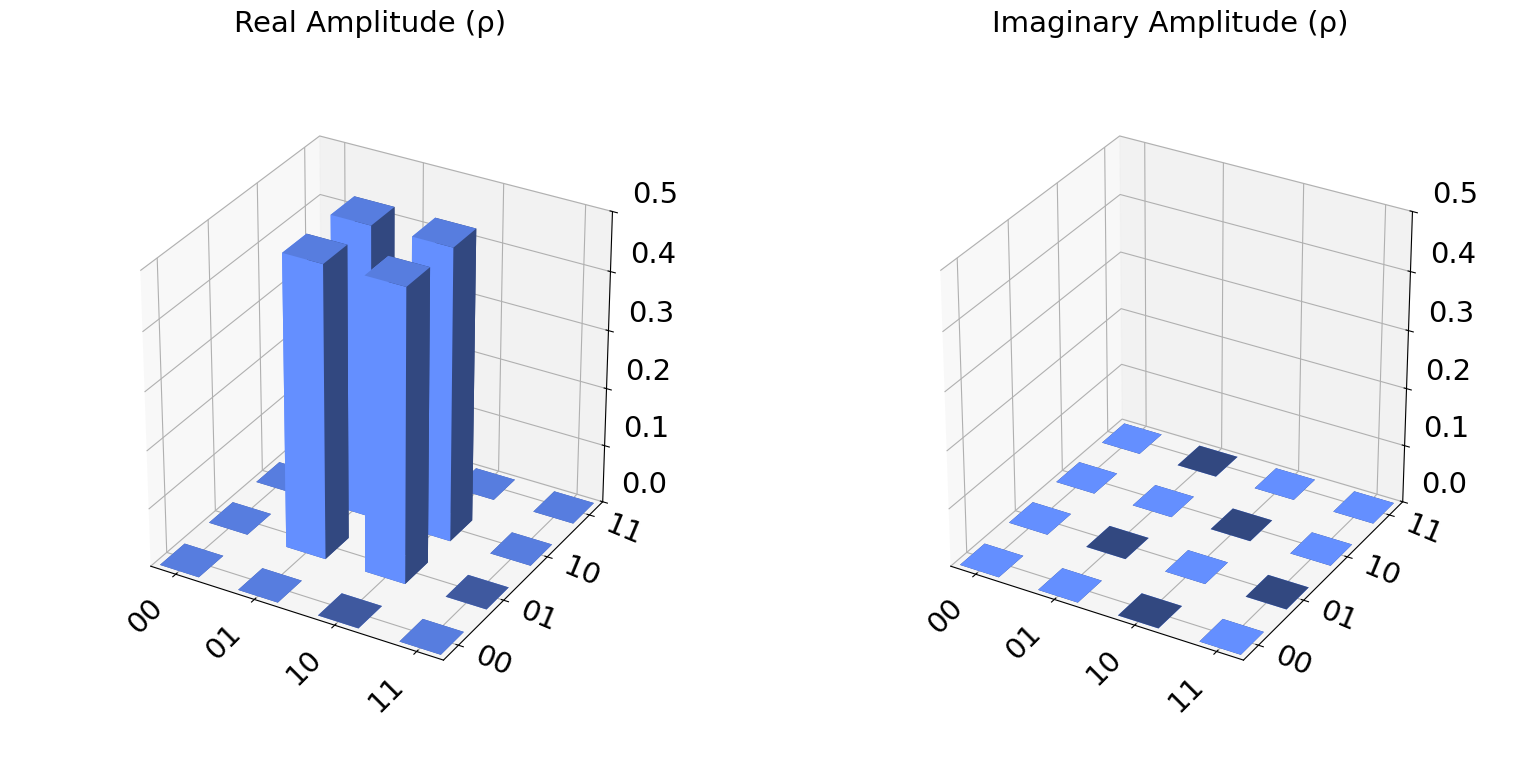

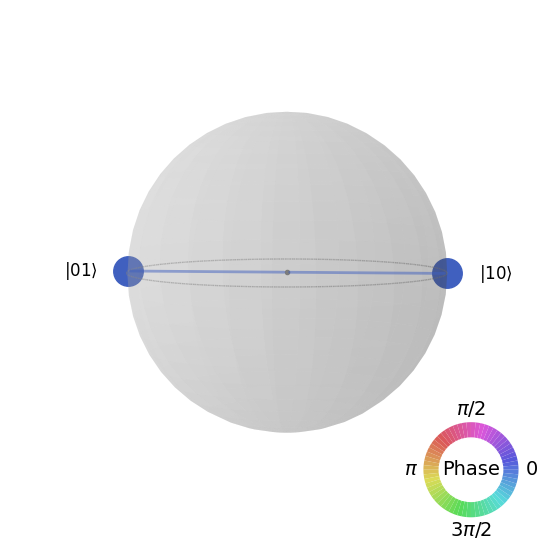

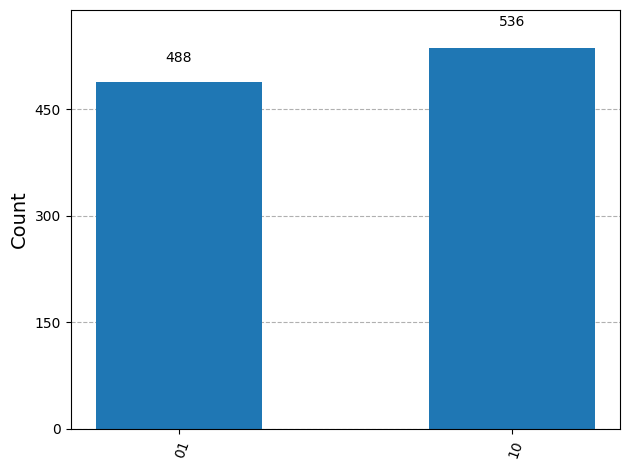

In [5]:
display(qc.draw("mpl"))                       # circuit diagram
display(state.draw("latex"))                  # state vector as a ket
display(DensityMatrix(state).draw("latex"))   # density matrix
display(state.draw("city"))                   # state-city plot
display(state.draw("qsphere"))                # Q-sphere
display(plot_histogram(counts))               # measurement counts from the Aer simulator

**Observation.** The cell above renders six complementary views of the same Bell state $|\Psi^+\rangle$; each figure confirms a different property of the prepared circuit, and together they connect the algebraic description of the state to the frequencies that are actually measured.

1. The first figure is the *circuit diagram*, which reproduces the gate sequence as a wire diagram: the Hadamard gate acting on q0, the Pauli-X gate acting on q1, the CNOT gate with q0 as control and q1 as target, and the two final measurements. This view confirms that the circuit was constructed in Qiskit exactly as specified.

2. The second figure is the *state vector* in ket notation, $\tfrac{1}{\sqrt2}|01\rangle + \tfrac{1}{\sqrt2}|10\rangle$. Only the basis states $|01\rangle$ and $|10\rangle$ carry a non-zero amplitude, each equal to $1/\sqrt2 \approx 0.707$, whereas the amplitudes of $|00\rangle$ and $|11\rangle$ are exactly zero; this is the algebraic form of the Bell state $|\Psi^+\rangle$.

3. The third figure is the *density matrix* $\rho = |\psi\rangle\langle\psi|$, a $4\times4$ matrix whose only non-zero entries lie in the rows and columns of $|01\rangle$ and $|10\rangle$, each equal to $0.5$. The two diagonal entries represent the probabilities of measuring $|01\rangle$ and $|10\rangle$, whereas the two off-diagonal entries are the coherences; these coherence terms are the mathematical signature of quantum superposition, since a classical statistical mixture of $|01\rangle$ and $|10\rangle$ would populate only the diagonal (Nielsen & Chuang, 2010). Their presence therefore distinguishes a genuinely entangled state from a classical mixture.

4. The fourth figure is the *state-city plot*, a three-dimensional representation of the same density matrix in which the height of each bar corresponds to the value of the associated matrix element. Four bars of equal height $0.5$ rise at the positions associated with $|01\rangle$ and $|10\rangle$, which provides a visual counterpart to the numerical matrix and makes the absence of any other populated element immediately apparent.

5. The fifth figure is the *Q-sphere*, on which the two populated nodes correspond to $|01\rangle$ and $|10\rangle$. Both nodes are drawn with the same size, indicating equal probability, and with the same colour, indicating equal phase; consequently, the Q-sphere confirms not only that the two outcomes are equally likely but also that they share a common phase, as required by $|\Psi^+\rangle$.

6. The sixth figure is the *measurement histogram*, which displays the empirical counts obtained from the 1024-shot simulation, with approximately 512 occurrences of `01` and 512 of `10`. This histogram links the theory to the experiment: according to the Born rule, the probability of an outcome equals the squared magnitude of its amplitude, so $\left|1/\sqrt2\right|^2 = 0.5$ predicts the observed frequency of approximately 50% for each outcome (Nielsen & Chuang, 2010).

Overall, only `01` and `10` occur, at approximately 50% each, whereas `00` and `11` are absent. Although each qubit is individually random, the two qubits are perfectly anti-correlated; this anti-correlation is the experimental signature of the entangled state $|\Psi^+\rangle$.

### A.5 Run on the Quokka Quantum Device

The Quokka device does not accept a Qiskit circuit object directly; therefore, the circuit is exported to OpenQASM 2.0 text and sent to the device's HTTP API through a `POST` request.

### Export the Qiskit Circuit to Clean QASM

In [6]:
# Convert the Qiskit circuit to OpenQASM 2.0 string
qasm_string = qasm2.dumps(qc)
print("Qiskit QASM 2.0:\n", qasm_string)

# Write the string to a text file
with open("Task-2_Bell-pairs_qiskit.qasm", "w") as file:
    file.write(qasm_string)

print("File saved successfully as 'Task-2_Bell-pairs_qiskit.qasm'!")

Qiskit QASM 2.0:
 OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg meas[2];
h q[0];
x q[1];
cx q[0],q[1];
barrier q[0],q[1];
measure q[0] -> meas[0];
measure q[1] -> meas[1];
File saved successfully as 'Task-2_Bell-pairs_qiskit.qasm'!


### Import the QASM Back into Qiskit

OPENQASM 2.0;
qreg q[2];
creg meas[2];
h q[0];
x q[1];
cx q[0],q[1];
barrier q[0],q[1];
measure q[0] -> meas[0];
measure q[1] -> meas[1];


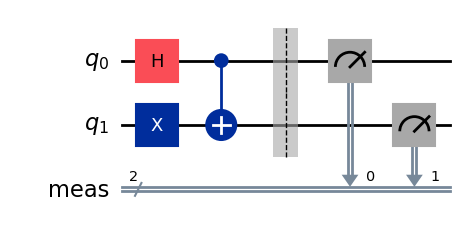

In [7]:
# Load the saved QASM back into a Qiskit circuit
circuitS = qasm2.load("Task-2_Bell-pairs_qiskit.qasm")

# Rebuild the QASM text and drop the `include "qelib1.inc";` line, which Quokka
# does not ship; a string match is safer than slicing by character position.
code = "\n".join(line for line in qasm2.dumps(circuitS).splitlines()
                 if 'include "qelib1.inc";' not in line)

print(code)
display(circuitS.draw("mpl"))

### Run on the Quokka Device

In [8]:
req_str_qasm = "http://quokka5.quokkacomputing.com/qsim/qasm"

data = {
    'script': code,
    'count': 1024
}

try:
    response = requests.post(req_str_qasm, json=data)

    # Catch non-200 responses before trying to parse JSON
    if response.status_code != 200:
        print(f"Server Error {response.status_code}: Server returned non-JSON data.")
        print("Response Snippet:", response.text[:200])
    else:
        results = response.json()
        print("Execution Results:", results)

    # Extract the raw per-shot bit-lists, ordered [meas[0], meas[1]]
    raw_shots = results['result']['meas']

    
    # little-endian convention, then join into a bitstring such as "10".
    string_shots = ["".join(map(str, shot[::-1])) for shot in raw_shots]

    # Aggregate the shots into a dictionary of counts
    quokka_counts = dict(Counter(string_shots))

    print("Quokka device counts:", quokka_counts)

except Exception as e:
    print("Error communicating with Quokka:", e)

Execution Results: {'error': 'no error', 'error_code': 0, 'result': {'meas': [[0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1], [1, 0], [1, 0], [1, 0], [0, 1], [1, 0], [1, 0], [1, 0], [0, 1], [1, 0], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [1, 0], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [1, 0], [0, 1], [1, 0], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [0, 1], [0, 1], [1, 0], [1, 0], [0, 1], [1, 0], [1, 0], [0, 1], [1, 0], [0, 1], [1, 0], [0, 1], [1, 0], [0, 1], [1, 0], [1

### A.6 Compare the Simulator and the Device

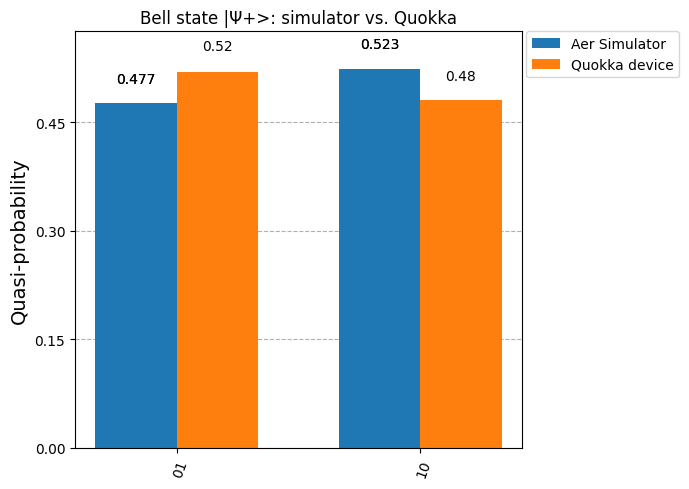

In [9]:
# plot_distribution normalises each dataset to probabilities, so the two
# 1024-shot runs compare fairly; it draws the grouped bars and the legend.
plot_distribution([counts, quokka_counts],
                  legend=["Aer Simulator", "Quokka device"],
                  title="Bell state |Ψ+>: simulator vs. Quokka")

### A.7 Analysis

The Bell state $|\Psi^+\rangle = \tfrac{1}{\sqrt2}(|01\rangle + |10\rangle)$ was constructed in Qiskit, verified on the local Aer simulator, where only the outcomes `01` and `10` were obtained, and subsequently executed on the Quokka device, which returned the same two outcomes at approximately 50% each and produced no spurious `00` or `11` counts. The state vector, the density matrix, the state-city plot, and the Q-sphere were used in order to visualise the anti-correlated structure of $|\Psi^+\rangle$ more clearly, and these views made the two equal amplitudes and their perfect anti-correlation immediately apparent.

A genuinely noisy physical processor would normally show a small number of counts in the forbidden outcomes `00` and `11`; however, the Quokka results match those of the ideal simulator, which suggests that the device behaves as an emulated, noise-free quantum processor. Although the label order returned by the device is reversed relative to Qiskit's little-endian convention, and is therefore corrected before the counts are aggregated, the comparison between the simulator and the device confirms that the two measured distributions are statistically consistent; consequently, the result supports the conclusion that the circuit prepares the entangled state $|\Psi^+\rangle$.

## References

Nielsen, M. A., & Chuang, I. L. (2010). *Quantum computation and quantum information* (10th anniversary ed.). Cambridge University Press.

Qiskit Contributors. (n.d.). *Qiskit: An open-source framework for quantum computing* (Version 2.4.0) [Computer software]. IBM Quantum. Retrieved July 24, 2026, from https://www.ibm.com/quantum/qiskit

Quokka Computing. (n.d.). *Quokka quantum computer* [Apparatus]. Retrieved July 24, 2026, from https://www.quokkacomputing.com